In [96]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [97]:
data = pd.read_csv("fmnist_small.csv")
data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


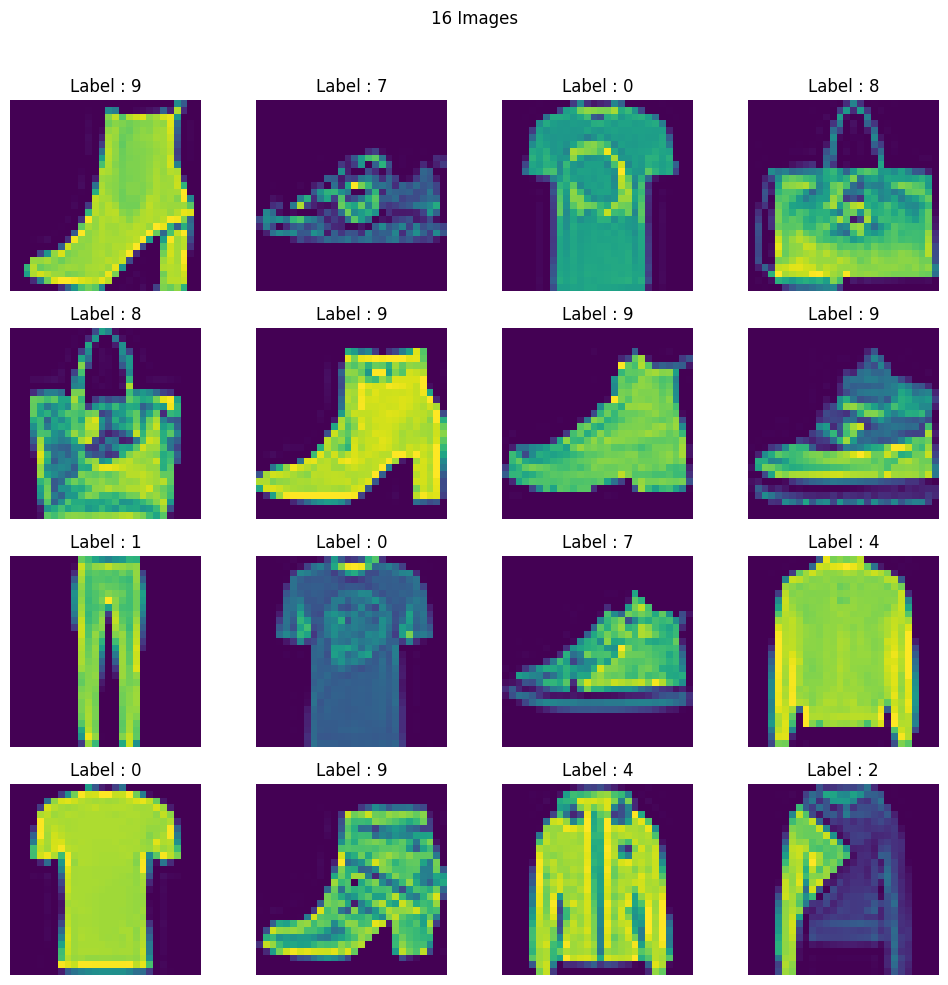

In [98]:
fig, axes = plt.subplots(4, 4, figsize = (10, 10))
fig.suptitle("16 Images")

for i, ax in enumerate(axes.flat):
    img = data.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Label : {data.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [99]:
X = data.drop("label", axis = 1)
y = data['label'].values

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [101]:
X_train = X_train/255.0
X_test = X_test/255.0

In [102]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        # Convert DataFrame to NumPy array before making it a Tensor
        features_array = features.values if hasattr(features, 'values') else features
        labels_array = labels.values if hasattr(labels, 'values') else labels
        
        self.features = torch.tensor(features_array, dtype=torch.float32).reshape(-1, 1, 28, 28)
        self.labels = torch.tensor(labels_array, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [103]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [104]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [105]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, input_features):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.4),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p = 0.4),
            
            nn.Linear(64, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        
        return x

In [106]:
learning_rate = 0.01
epochs = 25
model = NeuralNetwork(1)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [107]:
for epoch in range(epochs):
    
    total_epoch_loss = 0
    
    for batch_feature, batch_label in train_loader:
        
        # forward pass
        out = model(batch_feature)
        
        # loss function
        loss = criterion(out, batch_label)
        
        # back pass
        optimizer.zero_grad()
        loss.backward()
        
        # update grads
        optimizer.step()
        
        total_epoch_loss += loss.item()
    
    avg_loss = total_epoch_loss / len(train_loader)
    
    print(f"Epoch : {epoch+1} | Loss : {avg_loss}")

Epoch : 1 | Loss : 1.383479528427124
Epoch : 2 | Loss : 0.8116086105505625
Epoch : 3 | Loss : 0.6769578844308853
Epoch : 4 | Loss : 0.5757570962111155
Epoch : 5 | Loss : 0.523147949675719
Epoch : 6 | Loss : 0.46082702855269114
Epoch : 7 | Loss : 0.40279518634080885
Epoch : 8 | Loss : 0.38793573081493377
Epoch : 9 | Loss : 0.3487603951493899
Epoch : 10 | Loss : 0.3283408391972383
Epoch : 11 | Loss : 0.30182599353293577
Epoch : 12 | Loss : 0.26679749553402266
Epoch : 13 | Loss : 0.2519718366364638
Epoch : 14 | Loss : 0.24217514803012213
Epoch : 15 | Loss : 0.20502075197796027
Epoch : 16 | Loss : 0.1986889963100354
Epoch : 17 | Loss : 0.1811225443954269
Epoch : 18 | Loss : 0.16105839634935062
Epoch : 19 | Loss : 0.14894036872933308
Epoch : 20 | Loss : 0.13415206516782444
Epoch : 21 | Loss : 0.13407520045836765
Epoch : 22 | Loss : 0.1286619014851749
Epoch : 23 | Loss : 0.09990928349395593
Epoch : 24 | Loss : 0.09959075008518994
Epoch : 25 | Loss : 0.08666932327362398


In [108]:
model.eval()

NeuralNetwork(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [109]:
total = 0
correct = 0

with torch.no_grad():
    
    for batch_feature, batch_label in test_loader: 
        out = model(batch_feature)
        
        _, predicted = torch.max(out, 1)
        
        total = total + batch_label.shape[0]
        
        correct += (predicted == batch_label).sum().item()
    
    print(correct / total)

0.8725


In [110]:
total = 0
correct = 0

with torch.no_grad():
    
    for batch_feature, batch_label in train_loader: 
        out = model(batch_feature)
        
        _, predicted = torch.max(out, 1)
        
        total = total + batch_label.shape[0]
        
        correct += (predicted == batch_label).sum().item()
    
    print(correct / total)

0.994375
